# SANAQ PathNet v2 — обучение и анализ

Этот notebook последовательно создаёт/загружает `synthetic-outcomes-v2`, анализирует распределения, обучает PathNet, строит графики метрик и сохраняет checkpoint.

> Метрики показывают качество на синтетической holdout-выборке и не доказывают педагогическую эффективность на реальных учениках.

## 1. Окружение
Если зависимости ещё не установлены, раскомментируйте первую строку следующей ячейки.

In [1]:
# %pip install -r ../requirements-ml.txt
from pathlib import Path
import gzip
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

BACKEND_ROOT = Path.cwd().resolve()
if BACKEND_ROOT.name == 'notebooks':
    BACKEND_ROOT = BACKEND_ROOT.parent
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

print('Backend:', BACKEND_ROOT)
print('PyTorch:', torch.__version__)
print('Доступный ускоритель:', 'mps' if torch.backends.mps.is_available() else 'нет; используется CPU')

Matplotlib is building the font cache; this may take a moment.


Backend: /Users/artempinigin/SANAQ/backend
PyTorch: 2.13.0
Доступный ускоритель: mps


## 2. Настройки эксперимента

In [2]:
STUDENT_COUNT = 10_000
SEED = 20260817
EPOCHS = 12
BATCH_SIZE = 1024
LEARNING_RATE = 1e-3

ARTIFACTS = BACKEND_ROOT / 'ml' / 'artifacts'
DATASET_PATH = ARTIFACTS / 'synthetic-outcomes-v2-10k.jsonl.gz'
MODEL_PATH = ARTIFACTS / 'pathnet-v2-outcomes-notebook.pt'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
DATASET_PATH, MODEL_PATH

(PosixPath('/Users/artempinigin/SANAQ/backend/ml/artifacts/synthetic-outcomes-v2-10k.jsonl.gz'),
 PosixPath('/Users/artempinigin/SANAQ/backend/ml/artifacts/pathnet-v2-outcomes-notebook.pt'))

## 3. Создание датасета
Ячейка ничего не перезаписывает, если датасет уже существует. Для быстрого эксперимента можно уменьшить `STUDENT_COUNT`, изменить имя файла и перезапустить.

In [3]:
from ml.simulator import dataset_statistics, write_dataset

if not DATASET_PATH.exists():
    write_dataset(DATASET_PATH, STUDENT_COUNT, SEED)
stats = dataset_statistics(DATASET_PATH)
pd.Series(stats, name='value').to_frame()

,value
dataset_version,synthetic-outcomes-v2
students,10000
rows,973143
selection_rate,0.0556
completion_rate,0.2244
mean_expected_utility,0.0282
mean_realized_mastery_gain,0.0206


## 4. Исследование выборки и целевых меток

In [4]:
SAMPLE_ROWS = 100_000
records = []
with gzip.open(DATASET_PATH, 'rt', encoding='utf-8') as source:
    for index, line in enumerate(source):
        if index >= SAMPLE_ROWS:
            break
        row = json.loads(line)
        records.append({
            'selected': row['selected'],
            'priority': row['priority'],
            'status': row['status'],
            'blocked': row['is_blocked'],
            'completed': row['simulated_outcome']['completed'],
            'expected_gain': row['simulated_outcome']['expected_mastery_gain'],
            'realized_gain': row['simulated_outcome']['realized_mastery_gain'],
        })
sample = pd.DataFrame(records)
sample.describe(include='all')

,selected,priority,status,blocked,completed,expected_gain,realized_gain
count,100000.000000,100000.000000,100000,100000,100000,100000.000000,100000.000000
unique,NaN,NaN,6,2,2,NaN,NaN
top,NaN,NaN,blocked,True,False,NaN,NaN
freq,NaN,NaN,86631,90303,77751,NaN,NaN
mean,0.053880,0.027578,NaN,NaN,NaN,0.059652,0.020064
std,0.225782,0.069381,NaN,NaN,NaN,0.051804,0.052161
min,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000
25%,0.000000,0.004400,NaN,NaN,NaN,0.021800,0.000000
50%,0.000000,0.010500,NaN,NaN,NaN,0.051400,0.000000
75%,0.000000,0.017300,NaN,NaN,NaN,0.084500,0.000000


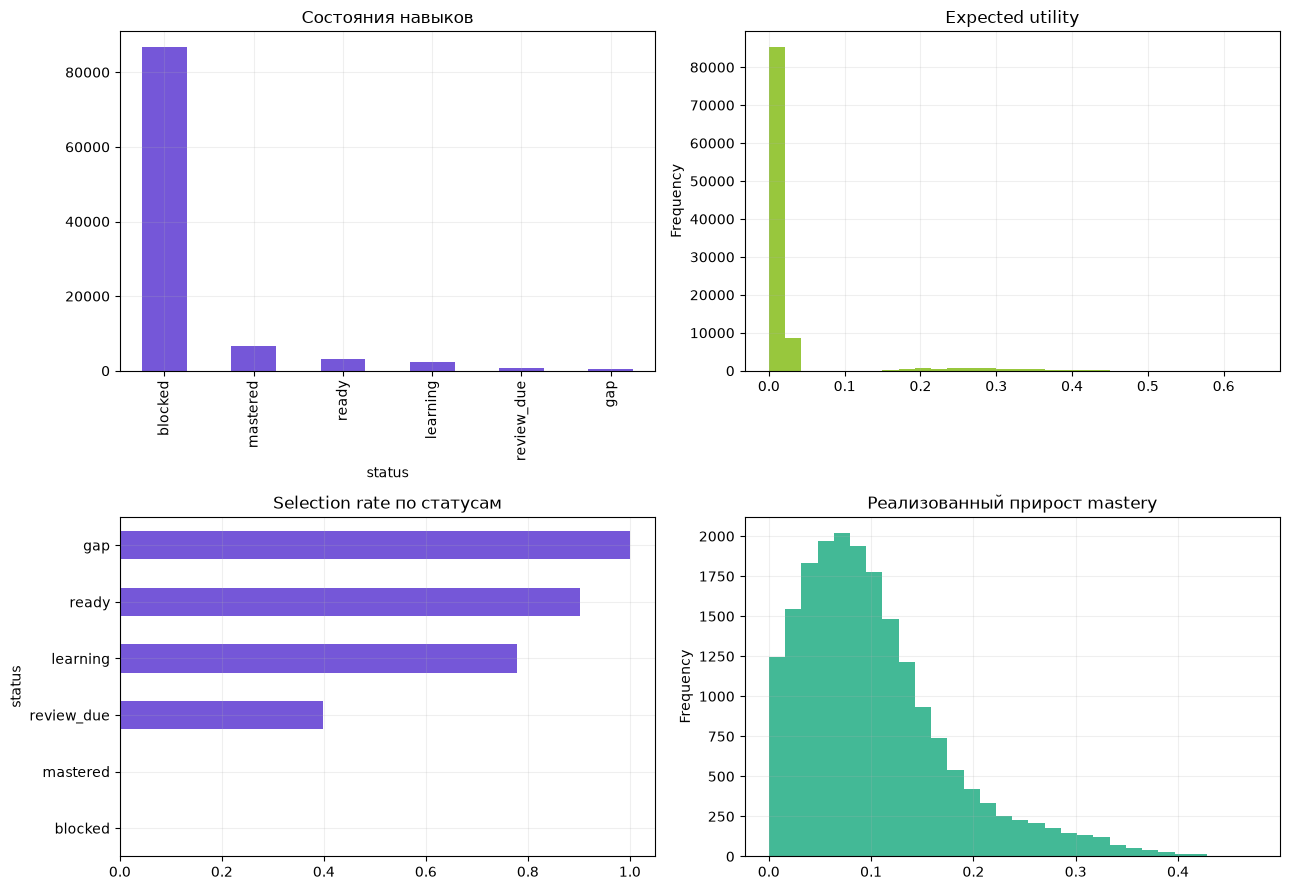

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sample['status'].value_counts().plot.bar(ax=axes[0, 0], color='#7557d8', title='Состояния навыков')
sample['priority'].plot.hist(ax=axes[0, 1], bins=30, color='#98c73d', title='Expected utility')
sample.groupby('status')['selected'].mean().sort_values().plot.barh(ax=axes[1, 0], color='#7557d8', title='Selection rate по статусам')
sample.loc[sample['realized_gain'] > 0, 'realized_gain'].plot.hist(ax=axes[1, 1], bins=30, color='#43b996', title='Реализованный прирост mastery')
for axis in axes.flat:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Загрузка полного датасета
Train/validation делятся по `student_id`, поэтому состояния одного ученика не попадают в обе части.

In [6]:
from ml.train_pathnet import load_dataset

dataset = load_dataset(DATASET_PATH)
print('Строк:', len(dataset))
print('Признаков:', dataset.tensors[0].shape[1])
print('Dataset version:', dataset.dataset_version)

Строк: 973143
Признаков: 15
Dataset version: synthetic-outcomes-v2


## 6. Обучение PathNet

In [7]:
from ml.train_pathnet import train

model, metrics = train(
    dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    progress=True,
)
pd.Series({key: value for key, value in metrics.items() if key not in {'history', 'validation_confusion_matrix'}}).to_frame('value')

/Users/artempinigin/SANAQ/backend/.venv-ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PathNet:   9%|▊         | 992/11424 [00:04<00:48, 216.83batch/s, epoch=2/12, loss=0.0437, phase=train]

Epoch 1/12: loss=0.1241, val_loss=0.0391, F1=0.9325, MAE=0.0109


PathNet:  17%|█▋        | 1945/11424 [00:09<00:46, 204.61batch/s, epoch=3/12, loss=0.0449, phase=train]

Epoch 2/12: loss=0.0435, val_loss=0.0382, F1=0.9325, MAE=0.0099


PathNet:  25%|██▌       | 2876/11424 [00:13<00:44, 193.24batch/s, epoch=4/12, loss=0.0400, phase=train]

...

PathNet:  92%|█████████▏| 10520/11424 [00:50<00:03, 275.30batch/s, epoch=12/12, loss=0.0397, phase=train]

Epoch 11/12: loss=0.0422, val_loss=0.0373, F1=0.9325, MAE=0.0067


PathNet: 100%|██████████| 11424/11424 [00:54<00:00, 209.45batch/s, epoch=12/12, phase=validation]        


Epoch 12/12: loss=0.0421, val_loss=0.0376, F1=0.9325, MAE=0.0067


,value
validation_accuracy,0.9921
validation_precision,0.8736
validation_recall,1.0000
validation_f1,0.9325
validation_priority_mae,0.0067
selection_rate,0.0556
majority_baseline_accuracy,0.9444
training_rows,828477.0000
validation_rows,144666.0000
training_students,8500.0000


## 7. Графики по эпохам

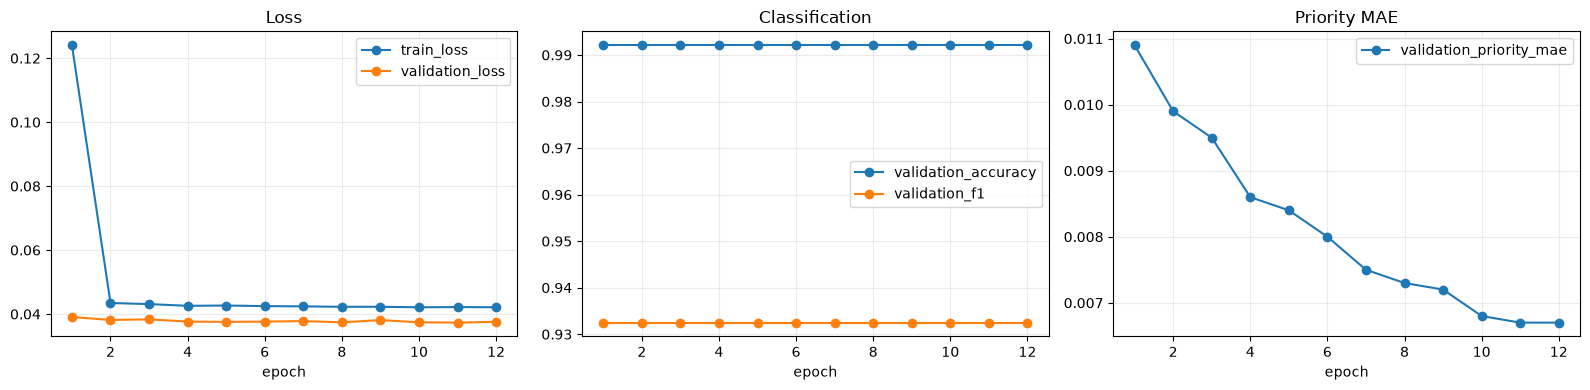

,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_priority_mae
0,1,0.124062,0.039069,0.9921,0.8736,1.0000,0.9325,0.0109
1,2,0.043460,0.038150,0.9921,0.8736,1.0000,0.9325,0.0099
2,3,0.043115,0.038340,0.9921,0.8736,1.0000,0.9325,0.0095
3,4,0.042573,0.037642,0.9921,0.8736,0.9999,0.9325,0.0086
4,5,0.042667,0.037541,0.9921,0.8736,1.0000,0.9325,0.0084
5,6,0.042485,0.037644,0.9921,0.8736,1.0000,0.9325,0.0080
6,7,0.042399,0.037800,0.9921,0.8736,1.0000,0.9325,0.0075
7,8,0.042266,0.037416,0.9921,0.8736,1.0000,0.9325,0.0073
8,9,0.042274,0.038115,0.9921,0.8736,1.0000,0.9325,0.0072
9,10,0.042115,0.037417,0.9921,0.8736,1.0000,0.9325,0.0068


In [8]:
history = pd.DataFrame(metrics['history'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
history.plot(x='epoch', y=['train_loss', 'validation_loss'], marker='o', ax=axes[0], title='Loss')
history.plot(x='epoch', y=['validation_accuracy', 'validation_f1'], marker='o', ax=axes[1], title='Classification')
history.plot(x='epoch', y='validation_priority_mae', marker='o', ax=axes[2], title='Priority MAE')
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()
history

## 8. Confusion matrix и сравнение с majority baseline

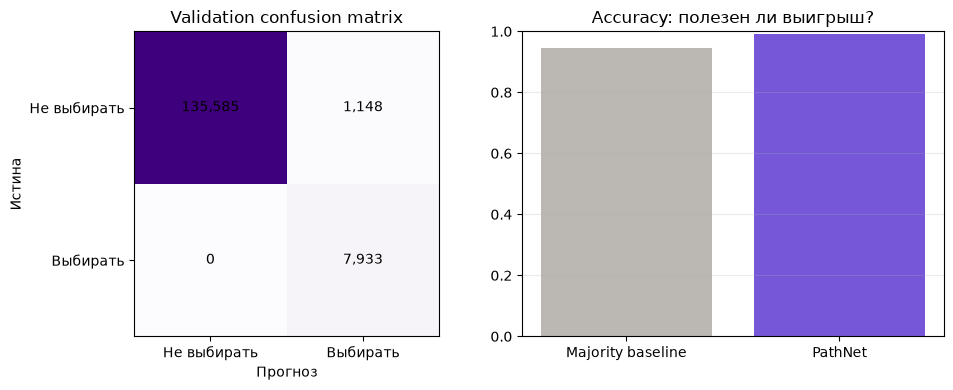

In [9]:
matrix = metrics['validation_confusion_matrix']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
image = axes[0].imshow(matrix, cmap='Purples')
axes[0].set_xticks([0, 1], ['Не выбирать', 'Выбирать'])
axes[0].set_yticks([0, 1], ['Не выбирать', 'Выбирать'])
axes[0].set_xlabel('Прогноз')
axes[0].set_ylabel('Истина')
axes[0].set_title('Validation confusion matrix')
for row in range(2):
    for column in range(2):
        axes[0].text(column, row, f'{matrix[row][column]:,}', ha='center', va='center')
axes[1].bar(['Majority baseline', 'PathNet'], [metrics['majority_baseline_accuracy'], metrics['validation_accuracy']], color=['#bbb7b2', '#7557d8'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Accuracy: полезен ли выигрыш?')
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Сохранение и повторная загрузка checkpoint

In [10]:
from ml.features import FEATURE_NAMES
from ml.pathnet import PathNet, parameter_count

checkpoint = {
    'model_state_dict': model.state_dict(),
    'feature_names': FEATURE_NAMES,
    'model_version': 'pathnet-v2-synthetic-outcomes-notebook',
    'dataset_version': dataset.dataset_version,
    'metrics': metrics,
}
torch.save(checkpoint, MODEL_PATH)
loaded = torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
restored = PathNet()
restored.load_state_dict(loaded['model_state_dict'])
restored.eval()
print('Checkpoint:', MODEL_PATH)
print('Размер:', f'{MODEL_PATH.stat().st_size / 1024:.1f} КБ')
print('Параметров:', parameter_count(restored))

Checkpoint: /Users/artempinigin/SANAQ/backend/ml/artifacts/pathnet-v2-outcomes-notebook.pt
Размер: 14.7 КБ
Параметров: 2090


## 10. Пример inference

In [11]:
features = dataset.tensors[0][:10]
with torch.inference_mode():
    output = restored(features)
pd.DataFrame({
    'selection_probability': torch.sigmoid(output['selection_logits']).numpy(),
    'predicted_priority': output['priority'].numpy(),
    'true_selected': dataset.tensors[1][:10].numpy(),
    'true_priority': dataset.tensors[2][:10].numpy(),
})

,selection_probability,predicted_priority,true_selected,true_priority
0,9.917876e-01,0.293607,1.0,0.2467
1,2.138532e-09,0.008210,0.0,0.0018
2,2.138532e-09,0.008210,0.0,0.0018
3,2.181505e-09,0.008274,0.0,0.0021
4,2.557248e-09,0.007635,0.0,0.0011
5,2.181505e-09,0.008274,0.0,0.0021
6,2.352807e-09,0.007651,0.0,0.0018
7,2.156251e-09,0.008111,0.0,0.0028
8,2.200268e-09,0.007694,0.0,0.0019
9,2.246358e-09,0.008071,0.0,0.0036


## 11. Подключение к shadow-mode
После проверки укажите созданный checkpoint при запуске backend:

```bash
PATHNET_MODE=shadow \
PATHNET_MODEL_PATH=ml/artifacts/pathnet-v2-outcomes-notebook.pt \
python3 -m flask --app app run --port 8000
```

Не включайте модель как основной planner на основании одних синтетических метрик.